In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["NIXTLA_ID_AS_COL"] = "true"
import numpy as np
np.set_printoptions(suppress=True)
np.random.seed(1)
import random
random.seed(1)
import pandas as pd
pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)
from utilsforecast.plotting import plot_series as plot_series_utils
import seaborn as sns
sns.set_style("whitegrid")
import matplotlib.pyplot as plt
plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "grid.alpha": 1.0,
})
import matplotlib as mpl
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#000000"])
from fpppy.utils import plot_series

mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#2f2fff"], name="black_and_blue"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00"], name="black_and_orange"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#000000"], name="black"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#0072B2", "#D55E00"],
        name='black_and_2color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73"],
        name='black_and_3color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='black_and_4color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='r_colors',
    ),
    force=True
)

In [2]:
from typing import Optional

from IPython.display import Image
from matplotlib.ticker import MaxNLocator
from statsforecast import StatsForecast
from statsforecast.arima import ARIMASummary, ndiffs, nsdiffs
from statsforecast.models import ARIMA, AutoARIMA, AutoETS
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import kpss
from utilsforecast.losses import rmse, mae

In [3]:
google = (
    pd.read_csv("gafa_stock.csv", parse_dates=["ds"])
    .loc[lambda x: (x["unique_id"] == "GOOG_Close")
        & (x["ds"].dt.year == 2015)
    ]
    .reset_index()
)

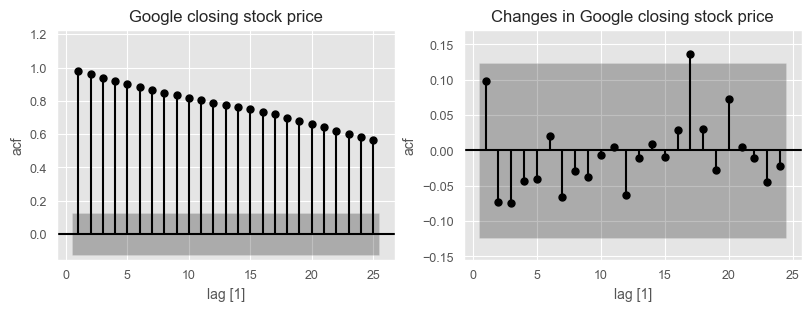

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
plot_acf(
    google["y"], ax=axes[0], zero=False,
    title="Google closing stock price",
    bartlett_confint=False, auto_ylims=True)
plot_acf(
    google["y"].diff().iloc[1:], ax=axes[1], zero=False,
    title="Changes in Google closing stock price",
    bartlett_confint=False, auto_ylims=True)
for ax in axes:
    ax.set(xlabel="lag [1]", ylabel="acf")
plt.show()

In [5]:
ljung_box = acorr_ljungbox(google["y"].diff()[1:], lags=[10])
ljung_box

,lb_stat,lb_pvalue
10,7.914,0.637


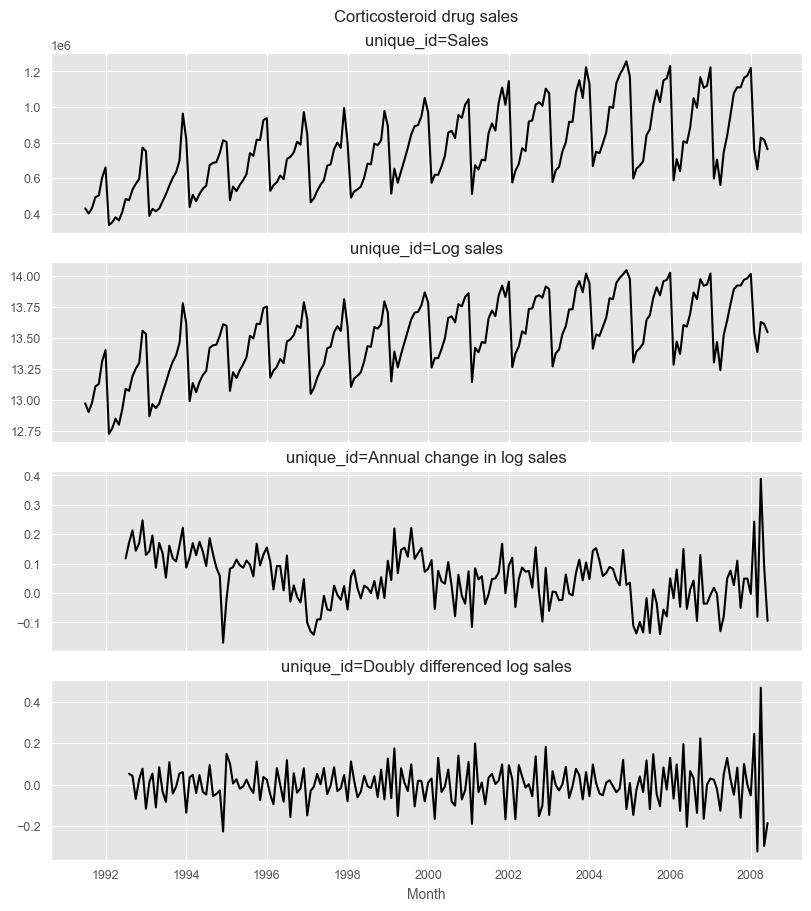

In [6]:
order = {
    "sales": 0, "log_sales": 1,
    "diff_log_sales": 2, "ddiff_log_sales": 3}
renames = {
    "sales": "Sales", "log_sales": "Log sales",
    "diff_log_sales": "Annual change in log sales",
    "ddiff_log_sales": "Doubly differenced log sales",
}
pbs = (
    pd.read_csv("PBS_unparsed.csv", parse_dates=["Month"])
    .rename(columns={"Month": "ds"})
    .loc[lambda x: x["ATC2"] == "H02"]
    .groupby("ds")["Cost"].sum()
    .rename("sales").reset_index()
    .assign(
        log_sales=lambda x: np.log(x["sales"]),
        diff_log_sales=lambda x: x["log_sales"].diff(12),
        ddiff_log_sales=lambda x: x["diff_log_sales"].diff(),
    )
    # Rearrange into long form
    .melt(id_vars=["ds"], var_name="unique_id", value_name="y")
    .assign(order=lambda x: x["unique_id"].map(order))
    .sort_values(["order", "ds"])
    .assign(unique_id=lambda x: x["unique_id"].map(renames))
)

fig, axes = plt.subplots(4, figsize=(8, 9), sharex=True)
plot_series_utils(pbs, ax=axes)
for ax in axes:
    ax.set(ylabel="")
    if ax.get_legend():
        ax.get_legend().remove()
    for label in ax.get_xticklabels():
        label.set_rotation(0)
ax.set(xlabel="Month")
fig.legends = []
fig.suptitle("Corticosteroid drug sales", x=0.525)
fig

In [7]:
kpss_stat, kpss_pvalue, *_ = kpss(google["y"], nlags = 5)
print(f"kpss_stat: {kpss_stat:.3f}")
print(f"kpss_pvalue: {kpss_pvalue:.2f}")

kpss_stat: 3.561
kpss_pvalue: 0.01


C:\Users\HP\AppData\Local\Temp\ipykernel_20276\1367699554.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_pvalue, *_ = kpss(google["y"], nlags = 5)


In [8]:
kpss_stat, kpss_pvalue, *_ = kpss(google["y"].diff()[1:], nlags=5)
print(f"kpss_stat: {kpss_stat:.3f}")
print(f"kpss_pvalue: {kpss_pvalue:.2f}")

kpss_stat: 0.099
kpss_pvalue: 0.10


C:\Users\HP\AppData\Local\Temp\ipykernel_20276\3486560393.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pvalue, *_ = kpss(google["y"].diff()[1:], nlags=5)


In [9]:
ndiffs(google["y"].to_numpy())

1

In [10]:
aus_total_retail = (
    pd.read_csv("aus_retail.csv", parse_dates=["Month"])
    .groupby("Month", as_index=False)
    ["Turnover"].sum()
    .assign(**{"log(Turnover)": lambda x: np.log(x["Turnover"])})
)

In [11]:
# Test for seasonal differencing
nsdiffs(aus_total_retail["log(Turnover)"].values, period=12)

1

In [12]:
# Apply seasonal difference before testing for first differencing
ndiffs(aus_total_retail["log(Turnover)"].diff(12)[1:].values)

1

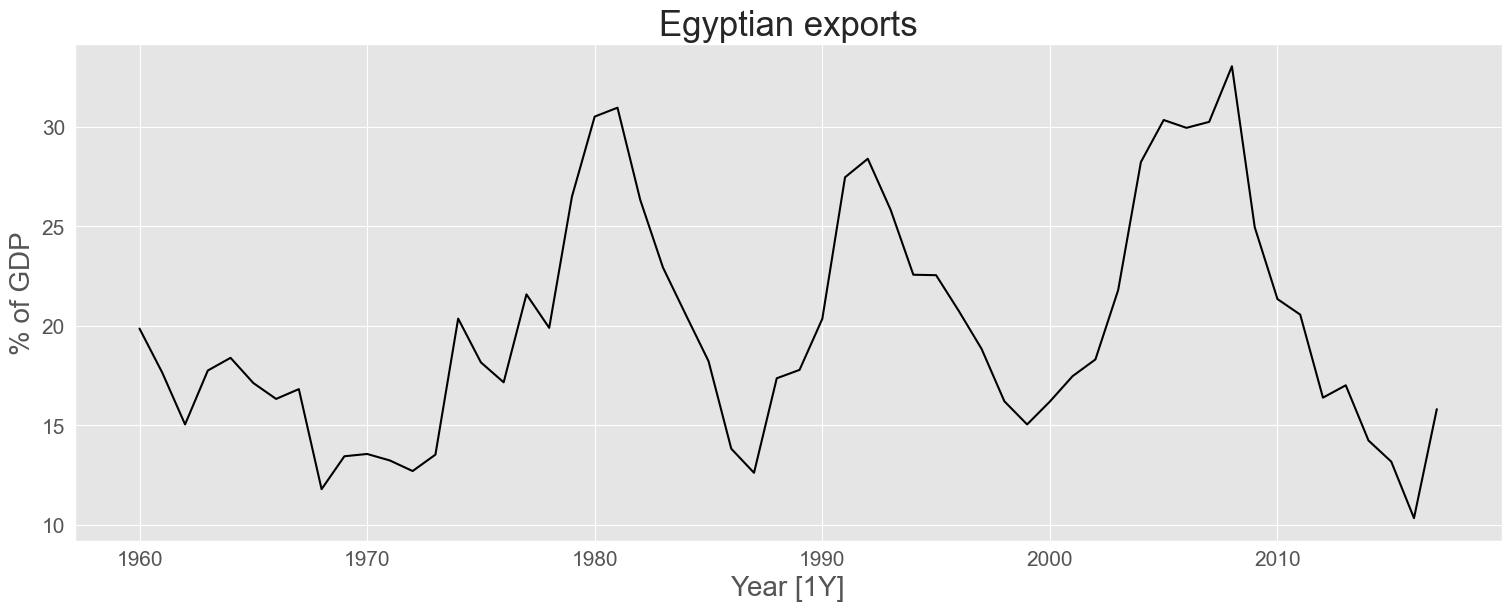

In [13]:
egyptian_economy = (
    pd.read_csv("global_economy.csv", parse_dates=[2])
    .rename(columns={"Exports": "y"})
    .loc[lambda x: x["Code"] == "EGY"]
    [["ds", "y", "unique_id"]]
)

plot_series(egyptian_economy,
    xlabel="Year [1Y]", ylabel="% of GDP", title="Egyptian exports")

In [14]:
models = [AutoARIMA(allowmean=True)]
sf = StatsForecast(models=models, freq="A", n_jobs=-1)
sf.fit(df=egyptian_economy)

model = sf.fitted_[0, 0].model_
coefs = {**model["coef"]}
coefs["mean"] = coefs.pop("intercept")
coefs = {k: round(v, 3) for k, v in coefs.items()}
coefs = pd.Series(coefs, name="Coefficients").round(3)
metrics = pd.Series({
    "sigma^2": model["sigma2"], "loglik": model["loglik"],
    "aic": model["aic"], "aicc": model["aicc"], "bic": model["bic"],
}, name="Metrics").round(2)

print(ARIMASummary(model), "\n")
print(coefs.to_frame(), "\n")
print(metrics.to_frame())

ARIMA(2,0,1) with non-zero mean 

      Coefficients
ar1          1.676
ar2         -0.803
ma1         -0.690
mean        20.179 

         Metrics
sigma^2     8.05
loglik   -141.57
aic       293.13
aicc      294.29
bic       303.43


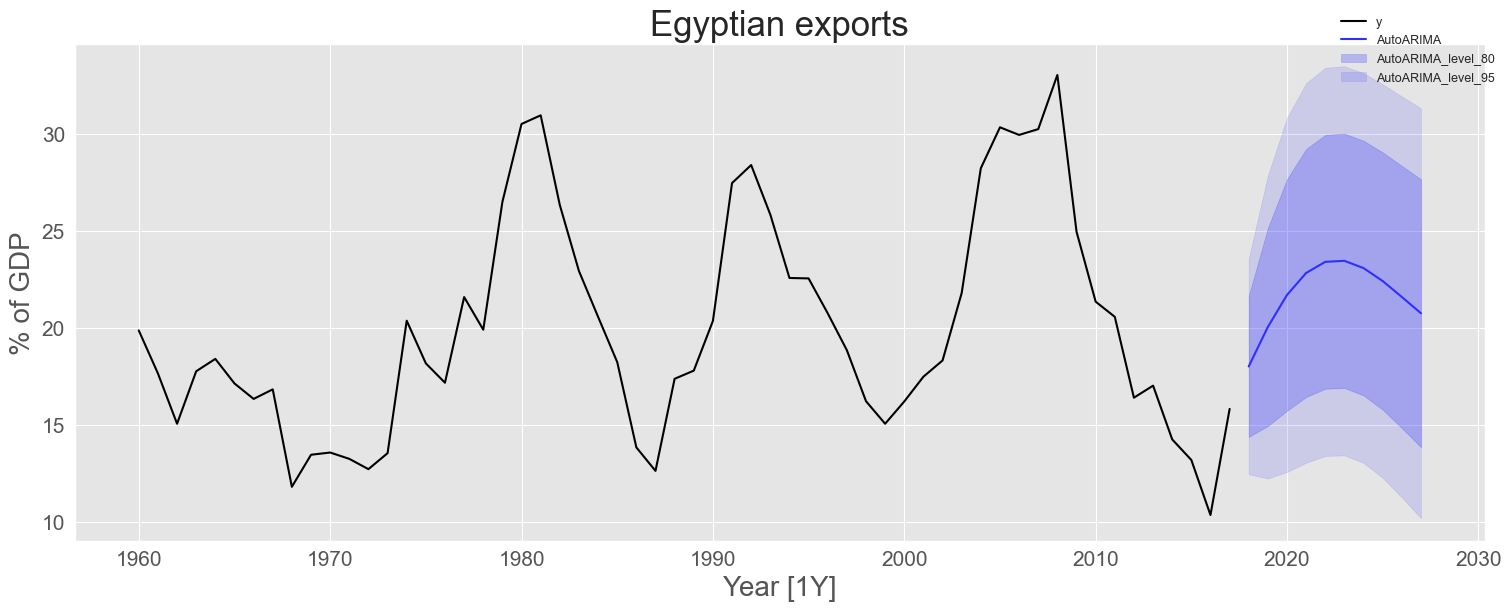

In [15]:
levels = [80, 95]
fc = sf.predict(h=10, level=levels)
plot_series(egyptian_economy, fc, level=levels,
    xlabel="Year [1Y]", ylabel="% of GDP", title="Egyptian exports",
    palette="black_and_blue", rm_legend=False)

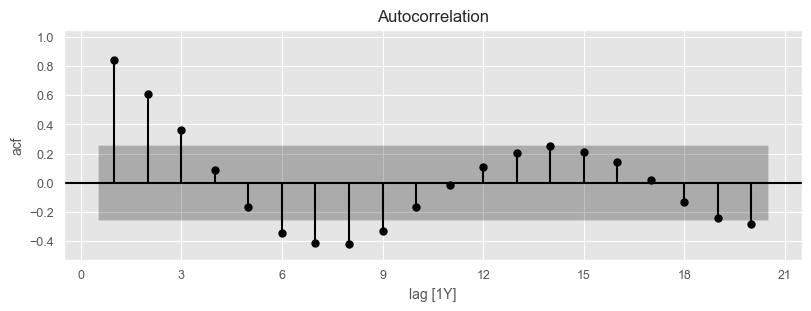

In [16]:
fig, ax = plt.subplots(figsize=(8, 3))
plot_acf(
    egyptian_economy["y"], lags=20, zero=False,
    bartlett_confint=False, ax=ax, auto_ylims=True)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set(xlabel="lag [1Y]", ylabel="acf")
plt.show()

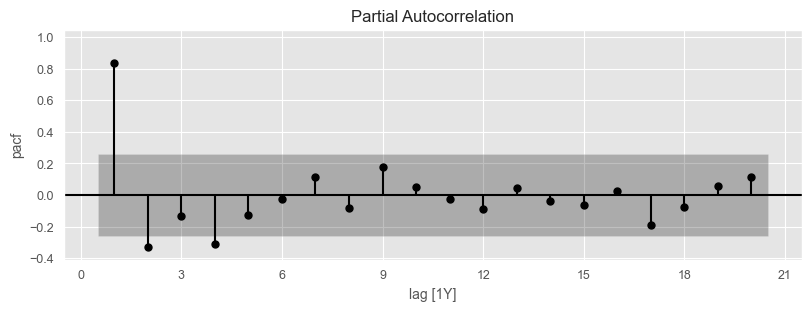

In [17]:
fig, ax = plt.subplots(figsize=(8, 3))
fig = plot_pacf(
    egyptian_economy["y"], lags=20, zero=False,
    ax=ax, auto_ylims=True)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set(xlabel="lag [1Y]", ylabel="pacf")
plt.show()

In [18]:
models = [ARIMA(order=(4, 0, 0))]
sf = StatsForecast(models=models, freq="Y", n_jobs=-1)
sf.fit(df=egyptian_economy)
model = sf.fitted_[0, 0].model_
coefs = {**model["coef"]}
coefs["mean"] = coefs.pop("intercept")
coefs = pd.Series(coefs, name="Coefficients").round(3)
metrics = pd.Series({
    "sigma^2": model["sigma2"], "loglik": model["loglik"],
    "aic": model["aic"], "aicc": model["aicc"], "bic": model["bic"],
}, name="Metrics").round(2)

print(ARIMASummary(model), "\n")
print(coefs.to_frame(), "\n")
print(metrics.to_frame())

ARIMA(4,0,0) with non-zero mean 

      Coefficients
ar1          0.986
ar2         -0.172
ar3          0.181
ar4         -0.328
mean        20.099 

         Metrics
sigma^2     7.88
loglik   -140.53
aic       293.05
aicc      294.70
bic       305.41


In [19]:
caf_economy = (
    pd.read_csv("global_economy.csv", parse_dates=[2])
    .rename(columns={"Exports": "y"})
    .loc[lambda x: x["Code"] == "CAF"]
    [["unique_id", "ds", "y"]]
)

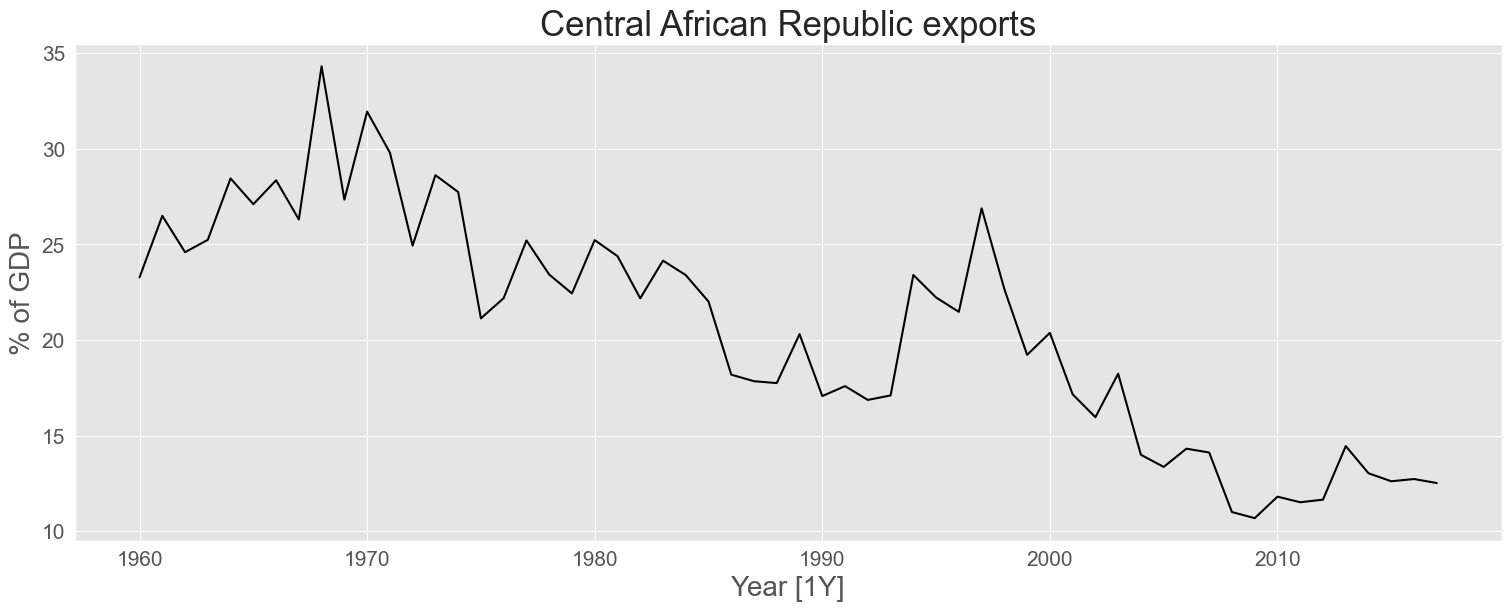

In [20]:
plot_series(caf_economy, xlabel="Year [1Y]", ylabel="% of GDP",
    title="Central African Republic exports")

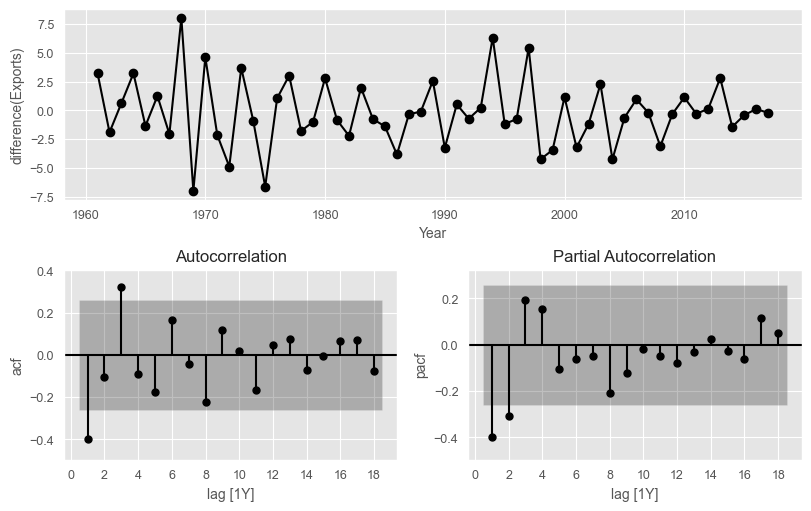

In [21]:
df = caf_economy.assign(diff=caf_economy["y"].diff()).iloc[1:]
fig, axes = plt.subplot_mosaic([["diff", "diff"], ["acf", "pacf"]])
axes["diff"].plot(df["ds"], df["diff"], marker="o")
axes["diff"].set(xlabel="Year", ylabel="difference(Exports)")
plot_acf(df["diff"], axes["acf"],
    zero=False, auto_ylims=True, bartlett_confint=False)
plot_pacf(df["diff"], axes["pacf"],
    zero=False, auto_ylims=True)
axes["acf"].set(xlabel="lag [1Y]", ylabel="acf")
axes["acf"].xaxis.set_major_locator(MaxNLocator(integer=True))
axes["pacf"].set(xlabel="lag [1Y]", ylabel="pacf")
axes["pacf"].xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

In [22]:
models = [
    ARIMA(order=(2, 1, 0), alias="arima210"),
    ARIMA(order=(0, 1, 3), alias="arima013"),
    AutoARIMA(alias="stepwise"),
    AutoARIMA(stepwise=False, alias="search"),
]
sf = StatsForecast(models=models, freq="A", n_jobs=-1)
sf.fit(caf_economy)
summaries = []
for model in sf.fitted_[0]:
    summary_model = {
        "model": model,
        "Orders": ARIMASummary(model.model_),
        "sigma2": model.model_["sigma2"],
        "loglik": model.model_["loglik"],
        "aic": model.model_["aic"],
        "aicc": model.model_["aicc"],
        "bic": model.model_["bic"],
    }
    summaries.append(summary_model)
pd.DataFrame(sorted(summaries, key=lambda d: d["aicc"]))

,model,Orders,sigma2,loglik,aic,aicc,bic
0,search,"ARIMA(3,1,0)",6.519,-133.006,274.012,274.781,282.184
1,arima210,"ARIMA(2,1,0)",6.706,-134.269,274.539,274.992,280.668
2,arima013,"ARIMA(0,1,3)",6.537,-133.130,274.261,275.030,282.433
3,stepwise,"ARIMA(2,1,2)",6.417,-132.124,274.248,275.425,284.463


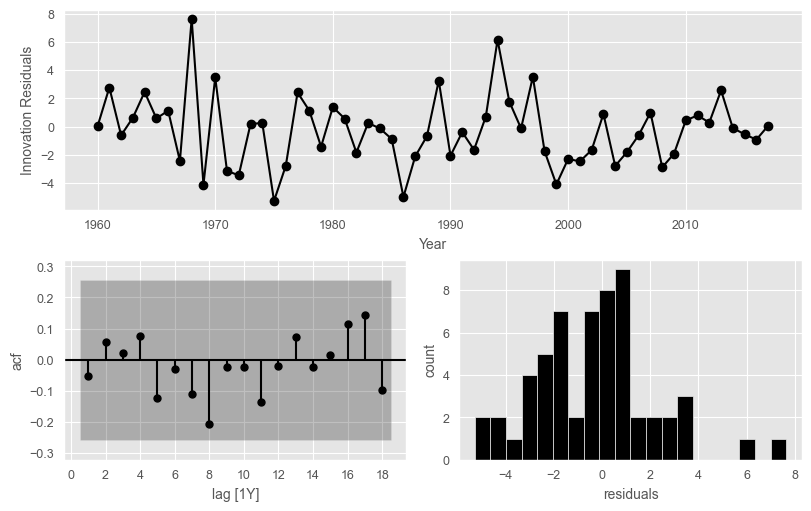

In [23]:
fc = sf.forecast(df=caf_economy, h=10, fitted=True, level=[80, 95])
insample = sf.forecast_fitted_values()
residuals = insample["y"] - insample["search"]

fig, axes = plt.subplot_mosaic([["resid", "resid"], ["acf", "hist"]])
axes["resid"].plot(caf_economy["ds"], residuals, marker="o")
axes["resid"].set(xlabel="Year", ylabel="Innovation Residuals")
plot_acf(residuals, axes["acf"], zero=False, auto_ylims=True,
    bartlett_confint=False)
axes["acf"].xaxis.set_major_locator(MaxNLocator(integer=True))
axes["acf"].set(xlabel="lag [1Y]", ylabel="acf", title="")
axes["hist"].hist(residuals, bins=20)
axes["hist"].set(xlabel="residuals", ylabel="count")
plt.show()

In [24]:
ljung_box = acorr_ljungbox(residuals, lags=[10], model_df=3)
ljung_box

,lb_stat,lb_pvalue
10,5.704,0.575


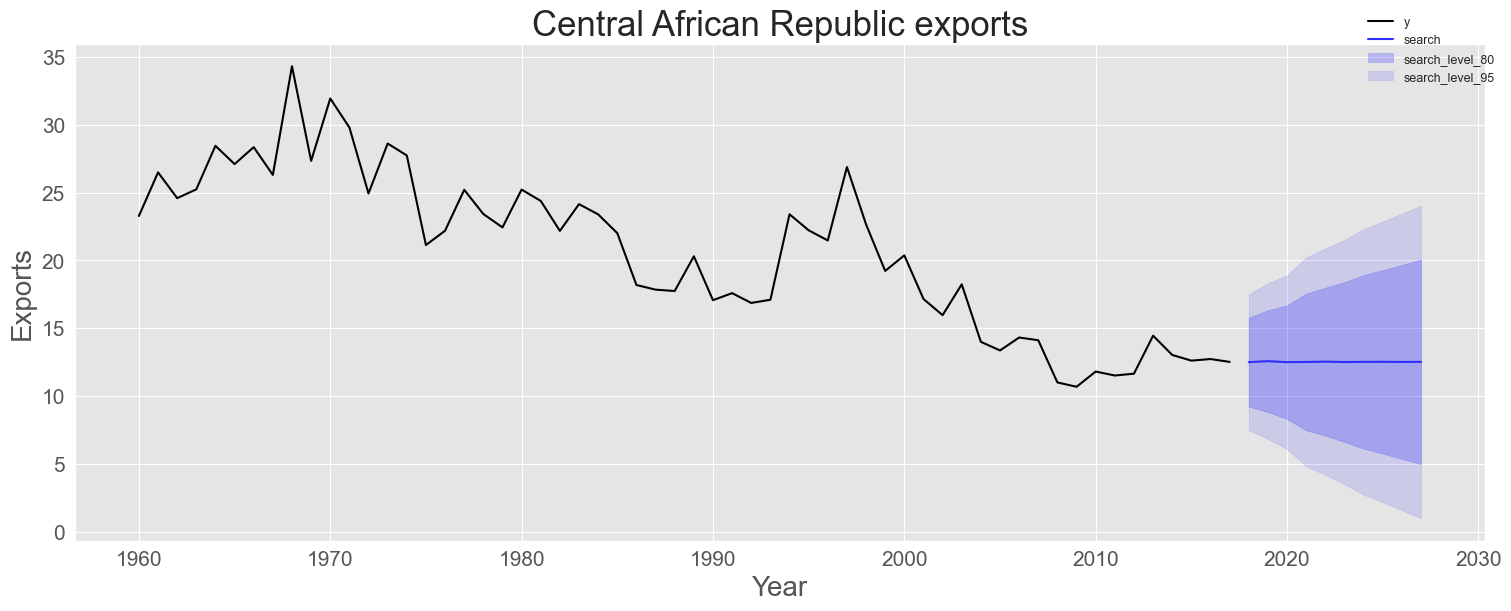

In [26]:
search_columns = fc.columns[fc.columns.str.startswith("search")]
search_fc = fc[["unique_id", "ds", *search_columns]]
plot_series(caf_economy, search_fc, level=[80, 95],
    xlabel="Year", ylabel="Exports",
    title="Central African Republic exports",
    palette="black_and_blue", rm_legend=False)

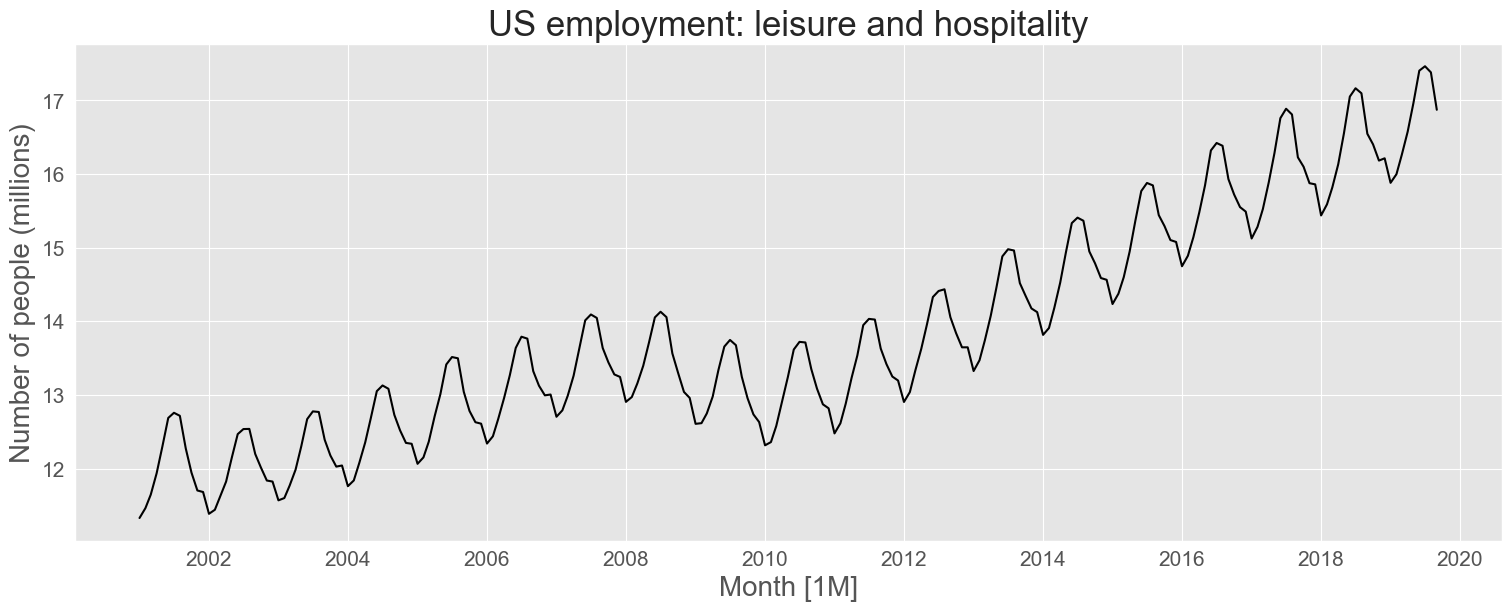

In [29]:
leisure = (
    pd.read_csv("us_employment.csv", parse_dates=["ds"])
    .loc[lambda x: (x["unique_id"] == "Leisure and Hospitality")
        & (x["ds"] >= "2001")
    ]
    .reset_index(drop=True)
    .assign(y=lambda x: x["y"] / 1e3)
    [["ds", "y", "unique_id"]]
)
plot_series(leisure,
    xlabel="Month [1M]", ylabel="Number of people (millions)",
    title="US employment: leisure and hospitality")

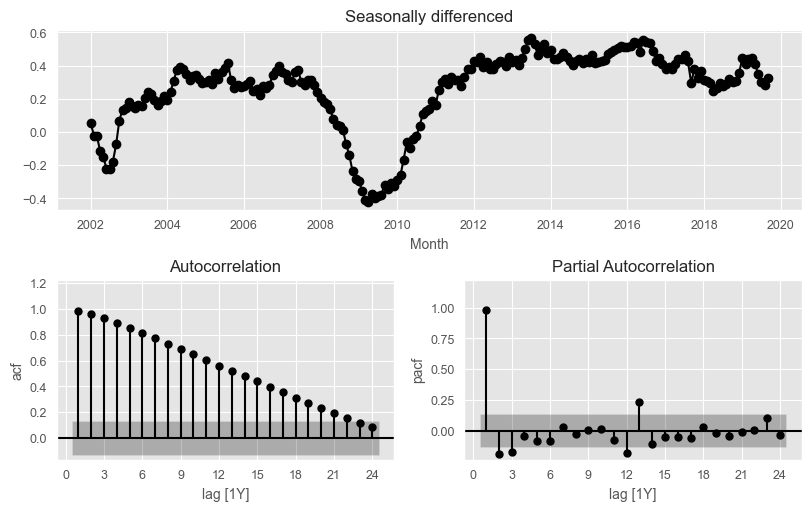

In [30]:
df = leisure.assign(diff=leisure["y"].diff(12)).iloc[12:]
fig, axes = plt.subplot_mosaic([["diff", "diff"], ["acf", "pacf"]])
axes["diff"].plot(df["ds"], df["diff"], marker="o")
axes["diff"].set(xlabel="Month", title="Seasonally differenced")
plot_acf(df["diff"], axes["acf"], lags=24,
    zero=False, auto_ylims=True, bartlett_confint=False)
plot_pacf(df["diff"], axes["pacf"], lags=24,
    zero=False, auto_ylims=True)
axes["acf"].set(xlabel="lag [1Y]", ylabel="acf")
axes["acf"].xaxis.set_major_locator(MaxNLocator(integer=True))
axes["pacf"].set(xlabel="lag [1Y]", ylabel="pacf")
axes["pacf"].xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

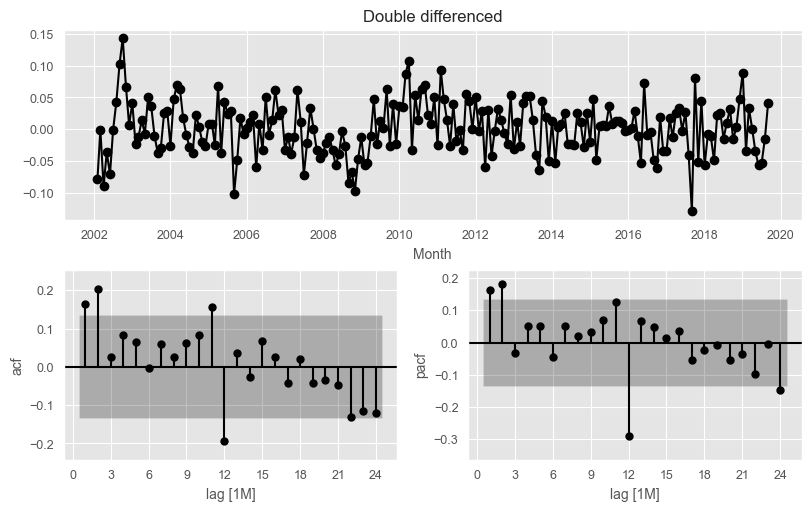

In [31]:
df = leisure.assign(
    diff=leisure["y"].diff(12),
    ddiff=lambda x: x["diff"].diff()
).iloc[13:]
fig, axes = plt.subplot_mosaic([["diff", "diff"], ["acf", "pacf"]])
axes["diff"].plot(df["ds"], df["ddiff"], marker="o")
axes["diff"].set(xlabel="Month", title="Double differenced")
plot_acf(df["ddiff"], axes["acf"], lags=24,
    zero=False, auto_ylims=True, bartlett_confint=False)
plot_pacf(df["ddiff"], axes["pacf"], lags=24,
    zero=False, auto_ylims=True)
axes["acf"].set(xlabel="lag [1M]", ylabel="acf", title="")
axes["acf"].xaxis.set_major_locator(MaxNLocator(integer=True))
axes["pacf"].set(xlabel="lag [1M]", ylabel="pacf", title="")
axes["pacf"].xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

In [32]:
models = [
    ARIMA(order=(0, 1, 2), seasonal_order=(0, 1, 1),
        season_length=12, alias="arima012011"),
    ARIMA(order=(2, 1, 0), seasonal_order=(0, 1, 1),
        season_length=12, alias="arima210011"),
    AutoARIMA(stepwise=False, approximation=False,
        alias="auto", season_length=12),
]
sf = StatsForecast(models=models, freq="MS", n_jobs=-1)
sf.fit(df=leisure)
summaries = []
for model in sf.fitted_[0]:
    summary_model = {
        "model": model,
        "Orders": ARIMASummary(model.model_),
        "sigma2": model.model_["sigma2"],
        "loglik": model.model_["loglik"],
        "aic": model.model_["aic"],
        "aicc": model.model_["aicc"],
        "bic": model.model_["bic"],
    }
    summaries.append(summary_model)
pd.DataFrame(sorted(summaries, key=lambda d: d["aicc"]))

,model,Orders,sigma2,loglik,aic,aicc,bic
0,auto,"ARIMA(2,1,0)(0,1,2)[12]",0.001,394.470,-778.940,-778.649,-762.157
1,arima210011,"ARIMA(2,1,0)(0,1,1)[12]",0.001,392.020,-776.040,-775.847,-762.613
2,arima012011,"ARIMA(0,1,2)(0,1,1)[12]",0.001,391.293,-774.586,-774.392,-761.159


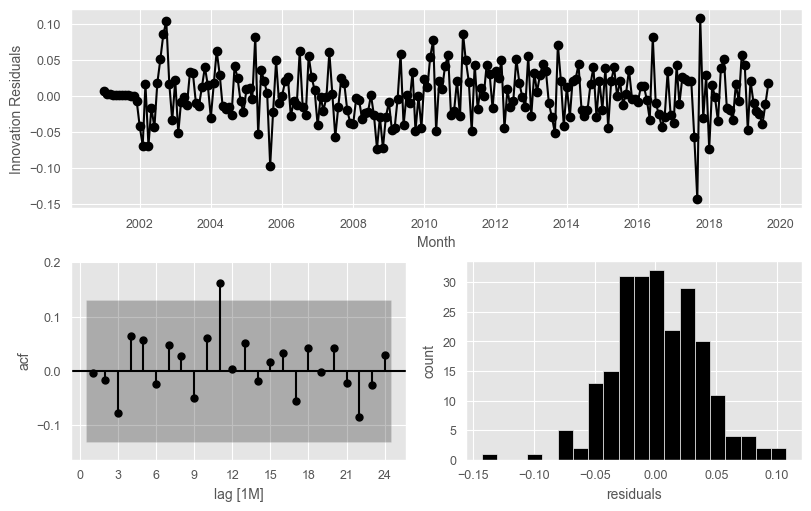

In [33]:
fc = sf.forecast(df=leisure, h=36, fitted=True, level=[80, 95])
insample = sf.forecast_fitted_values()
residuals = insample["y"] - insample["auto"]

fig, axes = plt.subplot_mosaic([["resid", "resid"], ["acf", "hist"]])
axes["resid"].plot(leisure["ds"], residuals, marker="o")
axes["resid"].set(xlabel="Month", ylabel="Innovation Residuals")
plot_acf(residuals, axes["acf"], zero=False, auto_ylims=True,
    bartlett_confint=False)
axes["acf"].xaxis.set_major_locator(MaxNLocator(integer=True))
axes["acf"].set(xlabel="lag [1M]", ylabel="acf", title="")
axes["hist"].hist(residuals, bins=20)
axes["hist"].set(xlabel="residuals", ylabel="count")
plt.show()

In [34]:
ljung_box = acorr_ljungbox(residuals, lags=[24], model_df=4)
ljung_box

,lb_stat,lb_pvalue
24,16.808,0.665


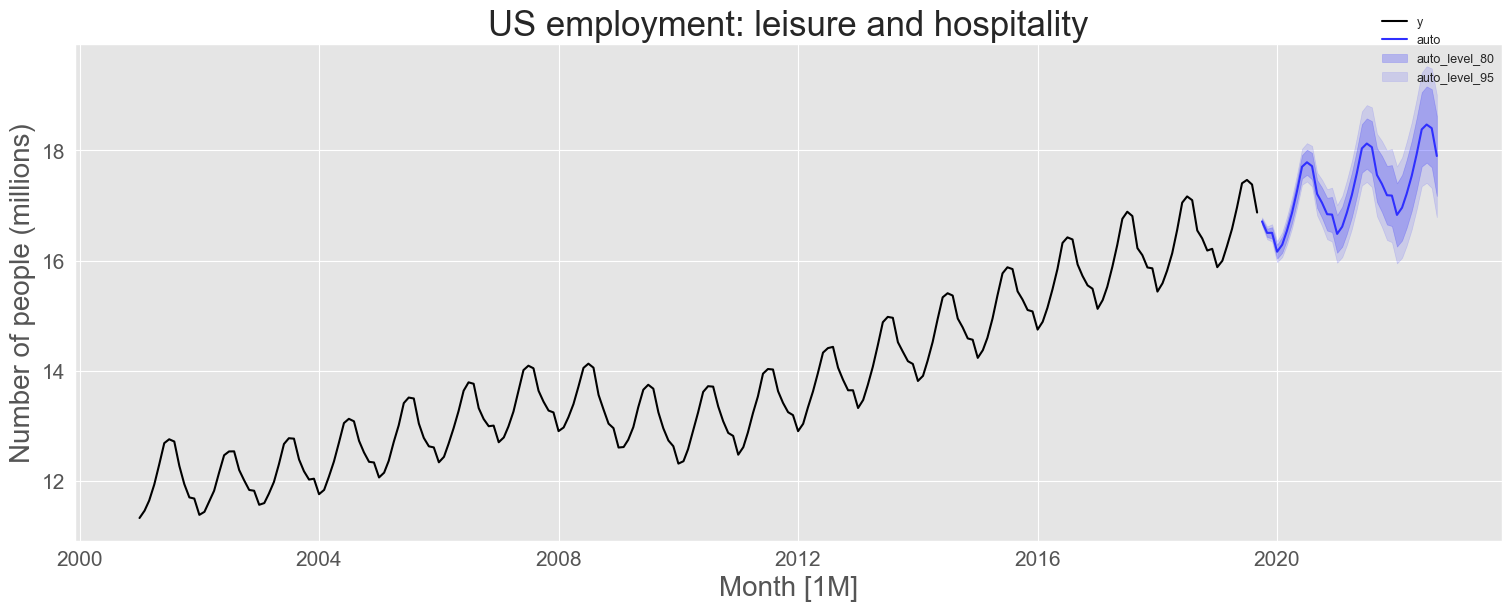

In [36]:
auto_columns = fc.columns[fc.columns.str.startswith("auto")]
auto_fc = fc[["unique_id", "ds", *auto_columns]]
plot_series(leisure, auto_fc, level=[80, 95],
    xlabel="Month [1M]", ylabel="Number of people (millions)",
    title="US employment: leisure and hospitality",
    palette="black_and_blue", rm_legend=False)

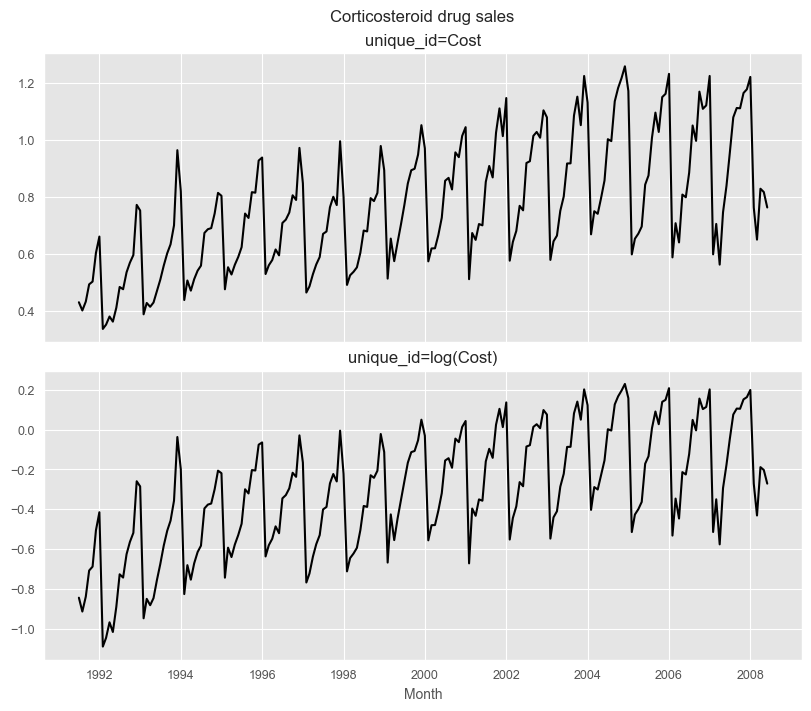

In [37]:
pbs = (
    pd.read_csv("PBS_unparsed.csv", parse_dates=["Month"])
    .rename(columns={"Month": "ds"})
    .loc[lambda x: x["ATC2"] == "H02"]
    .assign(Cost=lambda x: x["Cost"] / 1e6)
    .groupby("ds")["Cost"].sum().reset_index()
    .assign(**{"log(Cost)": lambda x: np.log(x["Cost"])})
    .melt(id_vars=["ds"], var_name="unique_id", value_name="y")
)

fig, axes = plt.subplots(2, figsize=(8, 7), sharex=True)
plot_series_utils(pbs, ax=axes)
for ax in axes:
    ax.set(ylabel="")
    if ax.get_legend():
        ax.get_legend().remove()
    for label in ax.get_xticklabels():
        label.set_rotation(0)
ax.set(xlabel="Month")
fig.legends = []
fig.suptitle("Corticosteroid drug sales", x=0.52)
fig

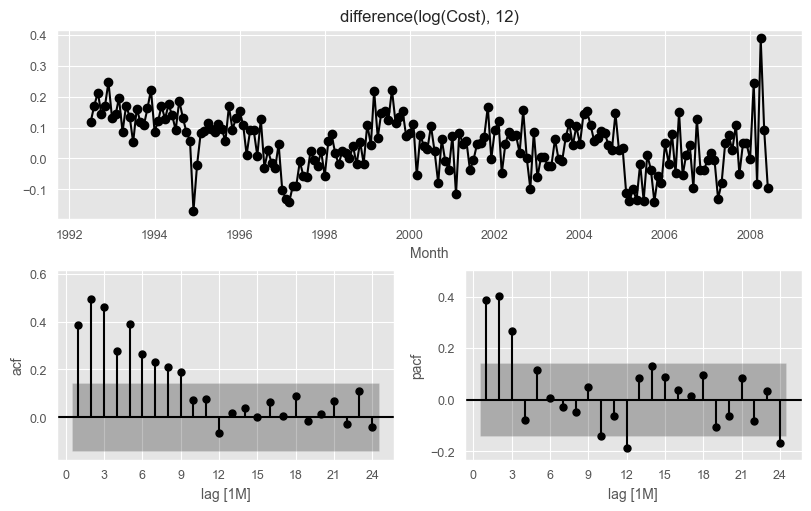

In [38]:
log_cost = pbs.loc[pbs["unique_id"] == "log(Cost)"]
df = log_cost.assign(diff=lambda x: x["y"].diff(12)).iloc[12:]
fig, axes = plt.subplot_mosaic([["diff", "diff"], ["acf", "pacf"]])
axes["diff"].plot(df["ds"], df["diff"], marker="o")
axes["diff"].set(xlabel="Month", title="difference(log(Cost), 12)")
plot_acf(df["diff"], axes["acf"], lags=24,
    zero=False, auto_ylims=True, bartlett_confint=False)
plot_pacf(df["diff"], axes["pacf"], lags=24,
    zero=False, auto_ylims=True)
axes["acf"].set(xlabel="lag [1M]", ylabel="acf", title="")
axes["acf"].xaxis.set_major_locator(MaxNLocator(integer=True))
axes["pacf"].set(xlabel="lag [1M]", ylabel="pacf", title="")
axes["pacf"].xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

In [39]:
models = [
    ARIMA(order=(3, 0, 0), seasonal_order=(2, 1, 0), season_length=12,
        alias="arima300210"),
    ARIMA(order=(3, 0, 1), seasonal_order=(2, 1, 0), season_length=12,
        alias="arima301210"),
    ARIMA(order=(3, 0, 2), seasonal_order=(2, 1, 0), season_length=12,
        alias="arima302210"),
    ARIMA(order=(3, 0, 1), seasonal_order=(1, 1, 0), season_length=12,
        alias="arima301110"),
    ARIMA(order=(3, 0, 1), seasonal_order=(0, 1, 1), season_length=12,
        alias="arima301011"),
    ARIMA(order=(3, 0, 1), seasonal_order=(0, 1, 2), season_length=12,
        alias="arima301012"),
    ARIMA(order=(3, 0, 1), seasonal_order=(1, 1, 1), season_length=12,
        alias="arima301111"),
]
sf = StatsForecast(models=models, freq="MS", n_jobs=-1)
sf.fit(df=log_cost)
summaries = []
for model in sf.fitted_[0]:
    summary_model = {
        "Model": model,
        "Orders": ARIMASummary(model.model_),
        "AICc": model.model_["aicc"],
    }
    summaries.append(summary_model)
sorted_summaries = pd.DataFrame(sorted(summaries, key=lambda d: d["AICc"]))
sorted_summaries.sort_values("AICc")

,Model,Orders,AICc
0,arima301012,"ARIMA(3,0,1)(0,1,2)[12]",-482.842
1,arima301011,"ARIMA(3,0,1)(0,1,1)[12]",-481.147
2,arima301111,"ARIMA(3,0,1)(1,1,1)[12]",-479.318
3,arima301210,"ARIMA(3,0,1)(2,1,0)[12]",-471.765
4,arima302210,"ARIMA(3,0,2)(2,1,0)[12]",-469.914
5,arima300210,"ARIMA(3,0,0)(2,1,0)[12]",-469.642
6,arima301110,"ARIMA(3,0,1)(1,1,0)[12]",-462.217


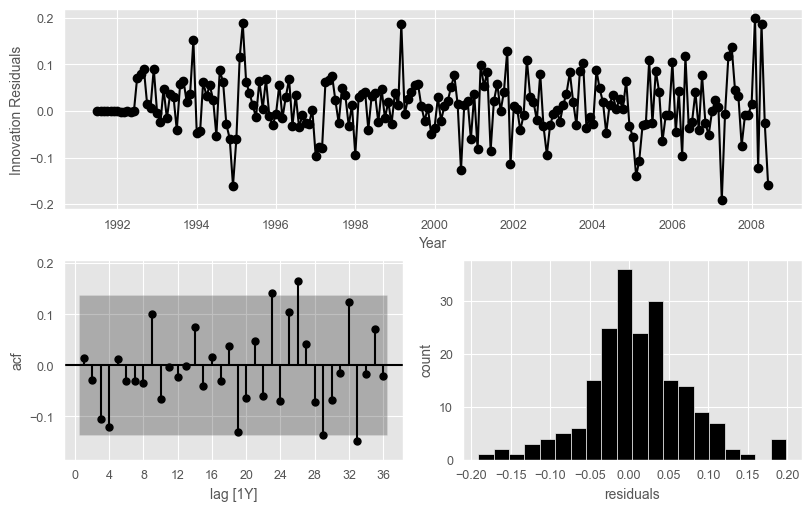

In [40]:
fc = sf.forecast(df=log_cost, h=24, fitted=True, level=[80, 95])
insample = sf.forecast_fitted_values()
residuals = insample["y"] - insample["arima301012"]

fig, axes = plt.subplot_mosaic([["resid", "resid"], ["acf", "hist"]])
axes["resid"].plot(insample["ds"], residuals, marker="o")
axes["resid"].set(xlabel="Year", ylabel="Innovation Residuals")
plot_acf(residuals, axes["acf"], zero=False, auto_ylims=True,
    bartlett_confint=False, lags=36)
axes["acf"].xaxis.set_major_locator(MaxNLocator(integer=True))
axes["acf"].set(xlabel="lag [1Y]", ylabel="acf", title="")
axes["hist"].hist(residuals, bins=20)
axes["hist"].set(xlabel="residuals", ylabel="count")
plt.show()

In [41]:
ljung_box = acorr_ljungbox(residuals, lags=[36], model_df=6)
ljung_box

,lb_stat,lb_pvalue
36,50.631,0.011


In [42]:
models = [
    ARIMA(order=(3, 0, 0), seasonal_order=(2, 1, 0), season_length=12,
        alias="arima300210"),
    ARIMA(order=(3, 0, 1), seasonal_order=(2, 1, 0), season_length=12,
        alias="arima301210"),
    ARIMA(order=(3, 0, 2), seasonal_order=(2, 1, 0), season_length=12,
        alias="arima302210"),
    ARIMA(order=(3, 0, 1), seasonal_order=(1, 1, 0), season_length=12,
        alias="arima301110"),
    ARIMA(order=(3, 0, 1), seasonal_order=(0, 1, 1), season_length=12,
        alias="arima301011"),
    ARIMA(order=(3, 0, 1), seasonal_order=(0, 1, 2), season_length=12,
        alias="arima301012"),
    ARIMA(order=(3, 0, 1), seasonal_order=(1, 1, 1), season_length=12,
        alias="arima301111"),
    ARIMA(order=(3, 0, 3), seasonal_order=(0, 1, 1), season_length=12,
        alias="arima303011"),
    ARIMA(order=(3, 0, 2), seasonal_order=(0, 1, 1), season_length=12,
        alias="arima302011"),
    ARIMA(order=(2, 1, 0), seasonal_order=(0, 1, 0), season_length=12,
        alias="arima210010"),
    ARIMA(order=(2, 1, 0), seasonal_order=(0, 1, 1), season_length=12,
        alias="arima210011"),
    ARIMA(order=(2, 1, 0), seasonal_order=(1, 1, 0), season_length=12,
        alias="arima210110"),
    ARIMA(order=(2, 1, 1), seasonal_order=(0, 1, 1), season_length=12,
        alias="arima211011"),
    ARIMA(order=(2, 1, 2), seasonal_order=(0, 1, 1), season_length=12,
        alias="arima212011"),
    ARIMA(order=(2, 1, 3), seasonal_order=(0, 1, 1), season_length=12,
        alias="arima213011"),
    ARIMA(order=(2, 1, 4), seasonal_order=(0, 1, 1), season_length=12,
        alias="arima214011"),
]

sf = StatsForecast(models=models, freq="MS", n_jobs=-1)
sf.fit(df=log_cost.iloc[:-24])
forecasts = sf.forecast(df=log_cost.iloc[:-24], h=24, level=[80, 95])
summaries = []
for model in sf.fitted_[0]:
    rmse_model = np.sqrt(
        np.mean(
            np.square(
                forecasts[str(model)].values-log_cost.iloc[-24:]["y"].values
            )
        )
    )
    summary_model = {
        "Model": model,
        "Orders": ARIMASummary(model.model_),
        "RMSE": rmse_model,
    }
    summaries.append(summary_model)
pd.DataFrame(sorted(summaries, key=lambda d: d["RMSE"]))

,Model,Orders,RMSE
0,arima213011,"ARIMA(2,1,3)(0,1,1)[12]",0.082
1,arima214011,"ARIMA(2,1,4)(0,1,1)[12]",0.082
2,arima212011,"ARIMA(2,1,2)(0,1,1)[12]",0.083
3,arima211011,"ARIMA(2,1,1)(0,1,1)[12]",0.083
4,arima210011,"ARIMA(2,1,0)(0,1,1)[12]",0.083
5,arima301012,"ARIMA(3,0,1)(0,1,2)[12]",0.084
6,arima303011,"ARIMA(3,0,3)(0,1,1)[12]",0.084
7,arima302011,"ARIMA(3,0,2)(0,1,1)[12]",0.085
8,arima301011,"ARIMA(3,0,1)(0,1,1)[12]",0.085
9,arima301210,"ARIMA(3,0,1)(2,1,0)[12]",0.086


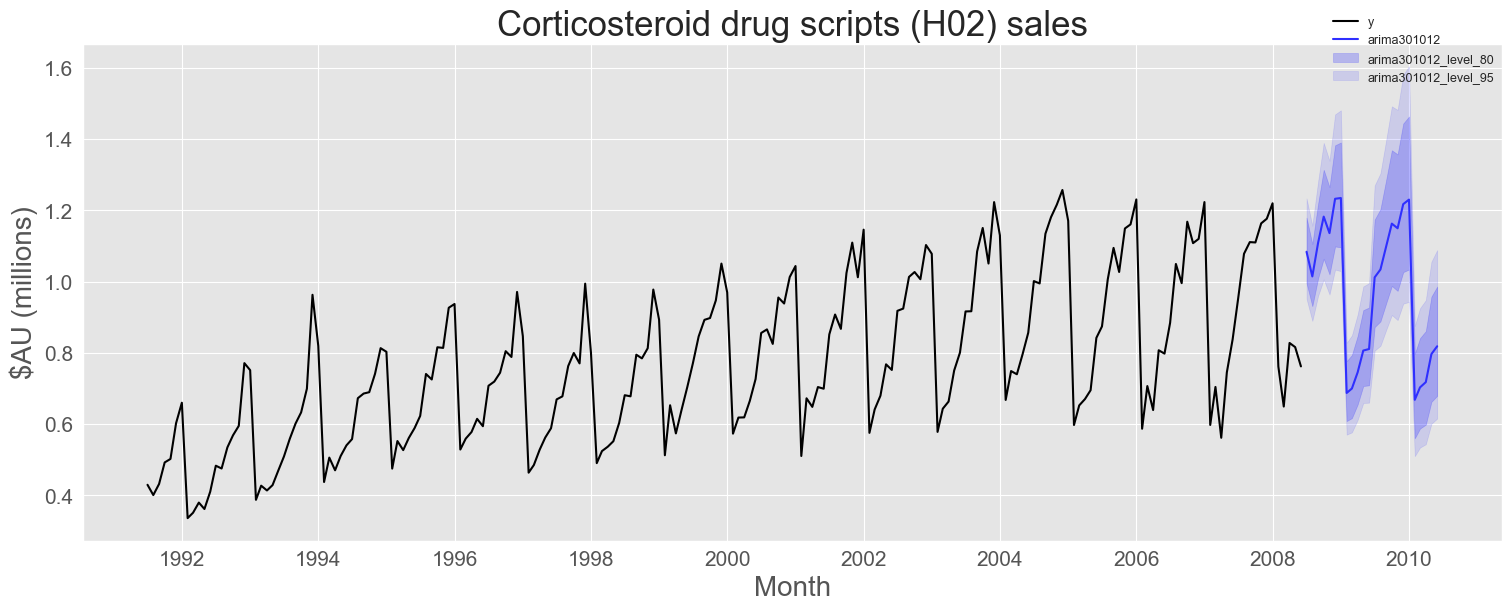

In [43]:
arima_cols = fc.columns[fc.columns.str.startswith("arima301012")]
backtransform_fc = fc[["ds", "unique_id"]].assign(**{
    col: np.exp(fc[col]) for col in arima_cols
})
df = log_cost.assign(y=lambda x: np.exp(x["y"]))
plot_series(df, backtransform_fc, level = [80, 95],
    xlabel="Month", ylabel="$AU (millions)",
    title="Corticosteroid drug scripts (H02) sales",
    palette="black_and_blue", rm_legend=False,
)

In [44]:
aus_economy = (
    pd.read_csv("aus_economy.csv", parse_dates=["ds"])
    .assign(y=lambda x: x["y"] / 1e6)
)
models = [AutoARIMA(), AutoETS()]
sf = StatsForecast(models=models, freq="A", n_jobs=-1)
cv_forecasts = sf.cross_validation(h=1, n_windows=10, df=aus_economy)

model_names = ["AutoARIMA", "AutoETS"]
rm = rmse(cv_forecasts, models=model_names, cutoff_col=None)
ma = mae(cv_forecasts, models=model_names, cutoff_col=None)
metrics = pd.concat([rm.assign(metric="RMSE"), ma.assign(metric="MAE")])
metrics[["metric", *model_names]]

,metric,AutoARIMA,AutoETS
0,RMSE,0.050,0.131
0,MAE,0.042,0.113


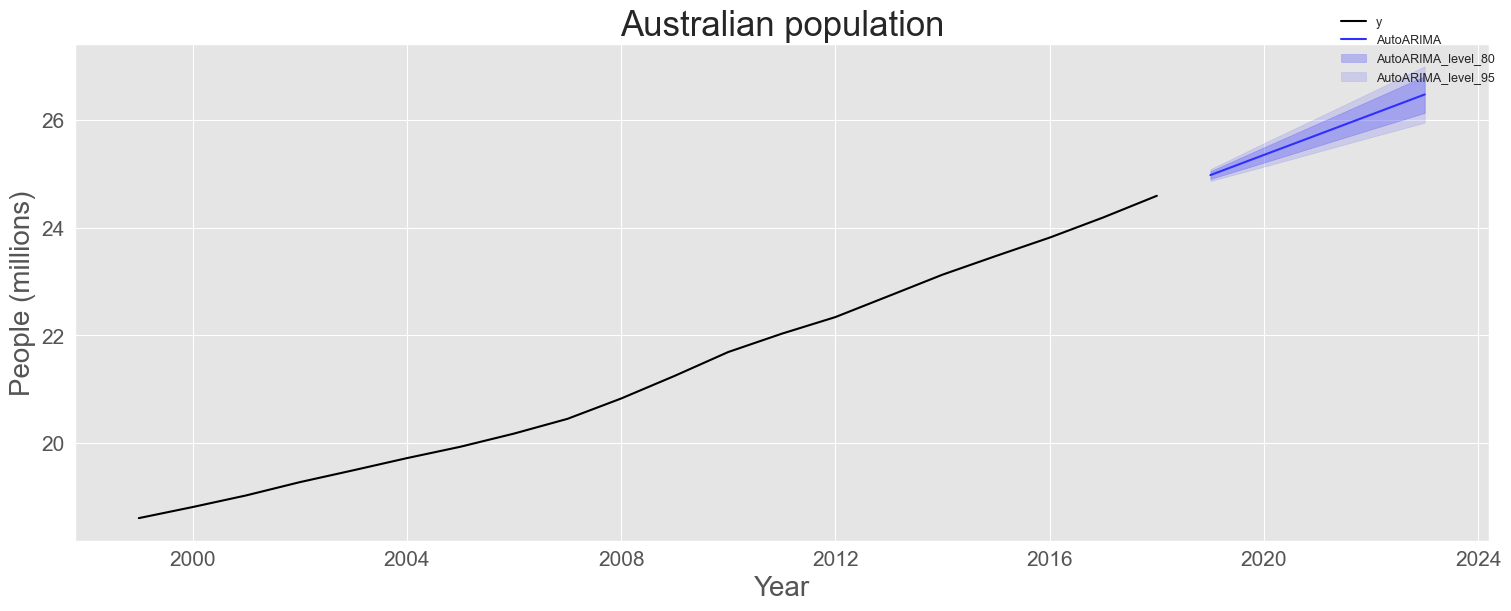

In [45]:
models = [AutoARIMA()]
sf = StatsForecast(models=models, freq="A", n_jobs=-1)
level = [80, 95]
fc = sf.forecast(h=5, df=aus_economy, level=level)
plot_series(aus_economy, fc, level=level, max_insample_length=20,
    xlabel="Year", ylabel="People (millions)",
    title="Australian population",
    palette="black_and_blue", rm_legend=False)

In [46]:
aus_production = pd.read_csv("aus_production.csv",
    parse_dates=["ds"])
cement = (
    aus_production.loc[lambda x: x["ds"] >= "1988"]
    [["ds", "Cement"]]
    .rename(columns={"Cement": "y"})
    .assign(unique_id="Cement")
)
train = cement.loc[lambda x: x["ds"] < "2008"].reset_index(drop=True)

In [47]:
arima = AutoARIMA(season_length=4, allowdrift=True)
arima_sf = StatsForecast(models=[arima], freq="QS", n_jobs=-1).fit(train)
arima_sf.forecast(df=train, h=10, fitted=True)
arima_insample = arima_sf.forecast_fitted_values()
arima_residuals = arima_insample["y"] - arima_insample["AutoARIMA"]

model = arima_sf.fitted_[0, 0].model_
coefs = {**model["coef"]}
coefs = pd.Series(coefs, name="Coefficients").round(3)
metrics = pd.Series({
    "sigma^2": model["sigma2"], "loglik": model["loglik"],
    "aic": model["aic"], "aicc": model["aicc"], "bic": model["bic"],
}, name="Metrics").round(2)

print(ARIMASummary(model), "\n")
print(coefs.to_frame(), "\n")
print(metrics.to_frame())

ARIMA(1,0,0)(1,1,2)[4] with drift         

       Coefficients
ar1           0.781
sar1         -0.507
sma1         -0.083
sma2         -0.624
drift         9.339 

          Metrics
sigma^2  12314.39
loglik    -465.49
aic        942.98
aicc       944.20
bic        956.97


In [48]:
ljung_box = acorr_ljungbox(arima_residuals, lags=[16], model_df=5)
ljung_box

,lb_stat,lb_pvalue
16,11.177,0.429


In [49]:
ets = AutoETS(season_length=4)
ets_sf = StatsForecast(models=[ets], freq="QS", n_jobs=-1).fit(train)
ets_sf.forecast(df=train, h=10, fitted=True)
ets_insample = ets_sf.forecast_fitted_values()
ets_residuals = ets_insample["y"] - ets_insample["AutoETS"]

model = ets_sf.fitted_[0, 0].model_
params = model["fit"].x
params = pd.Series({
    "alpha": params[0], "gamma": params[1], "l[0]": params[2],
    "s[0]": params[3], "s[1]": params[4],
    "s[2]": params[5], "s[3]": 4 - params[-3:].sum(),
}, name="Parameters").round(3)
metrics = pd.Series({
    "sigma^2": model["sigma2"], "loglik": model["loglik"],
    "aic": model["aic"], "aicc": model["aicc"], "bic": model["bic"],
}, name="Metrics").round(3)

print(model["method"], "\n")
print(params.to_frame(), "\n")
print(metrics.to_frame())

ETS(M,N,M) 

       Parameters
alpha       0.744
gamma       0.000
l[0]     1567.027
s[0]        1.031
s[1]        1.045
s[2]        1.012
s[3]        0.913 

          Metrics
sigma^2     0.003
loglik   -544.103
aic      1102.206
aicc     1103.761
bic      1118.880


In [50]:
ljung_box = acorr_ljungbox(ets_residuals, lags=[16])
ljung_box

,lb_stat,lb_pvalue
16,11.644,0.768


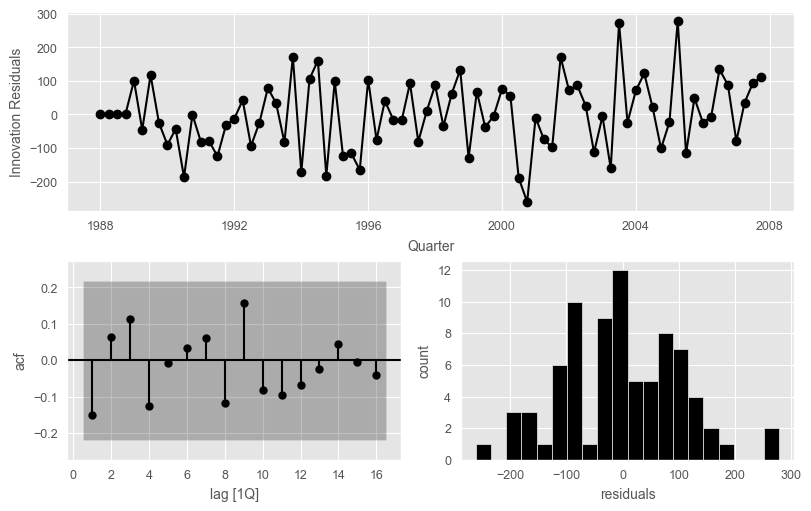

In [51]:
fig, axes = plt.subplot_mosaic([["resid", "resid"], ["acf", "hist"]])
axes["resid"].plot(arima_insample["ds"], arima_residuals, marker="o")
axes["resid"].set(xlabel="Quarter", ylabel="Innovation Residuals")
plot_acf(arima_residuals, axes["acf"], zero=False, auto_ylims=True,
    bartlett_confint=False, lags=16)
axes["acf"].xaxis.set_major_locator(MaxNLocator(integer=True))
axes["acf"].set(xlabel="lag [1Q]", ylabel="acf", title="")
axes["hist"].hist(arima_residuals, bins=20)
axes["hist"].set(xlabel="residuals", ylabel="count")
plt.show()

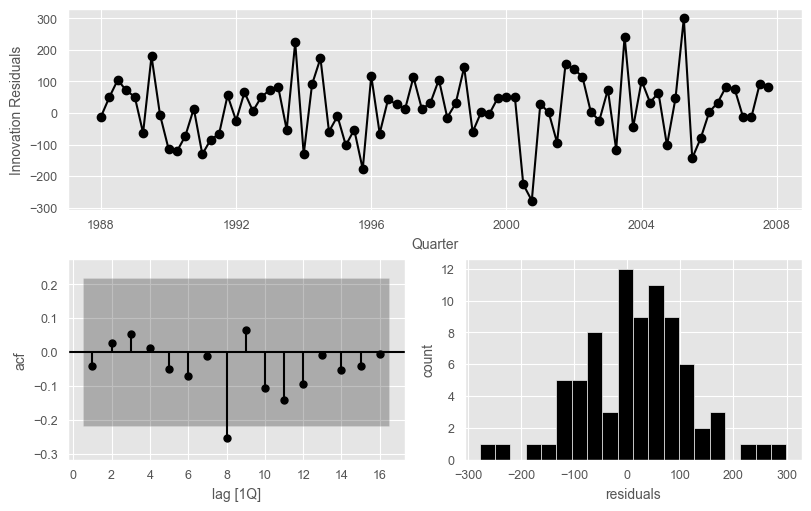

In [52]:
fig, axes = plt.subplot_mosaic([["resid", "resid"], ["acf", "hist"]])
axes["resid"].plot(ets_insample["ds"], ets_residuals, marker="o")
axes["resid"].set(xlabel="Quarter", ylabel="Innovation Residuals")
plot_acf(ets_residuals, axes["acf"], zero=False, auto_ylims=True,
    bartlett_confint=False, lags=16)
axes["acf"].xaxis.set_major_locator(MaxNLocator(integer=True))
axes["acf"].set(xlabel="lag [1Q]", ylabel="acf", title="")
axes["hist"].hist(ets_residuals, bins=20)
axes["hist"].set(xlabel="residuals", ylabel="count")
plt.show()

In [53]:
models = [AutoARIMA(season_length=4), AutoETS(season_length=4)]
sf = StatsForecast(models=models, freq="QS", n_jobs=-1)
fc = sf.forecast(h=10, df=train, fitted=True).merge(cement)
insample = sf.forecast_fitted_values()
dfs = {"Train": insample, "Test": fc}
metrics = pd.concat([
    metric(df, models=model_names)
    .assign(metric=metric.__name__.upper(), type=type)
    for type, df in dfs.items()
    for metric in [rmse, mae]
])[["type", "metric", *model_names]]
metrics

,type,metric,AutoARIMA,AutoETS
0,Train,RMSE,104.150,101.781
0,Train,MAE,82.308,79.029
0,Test,RMSE,298.443,222.180
0,Test,MAE,254.921,191.152


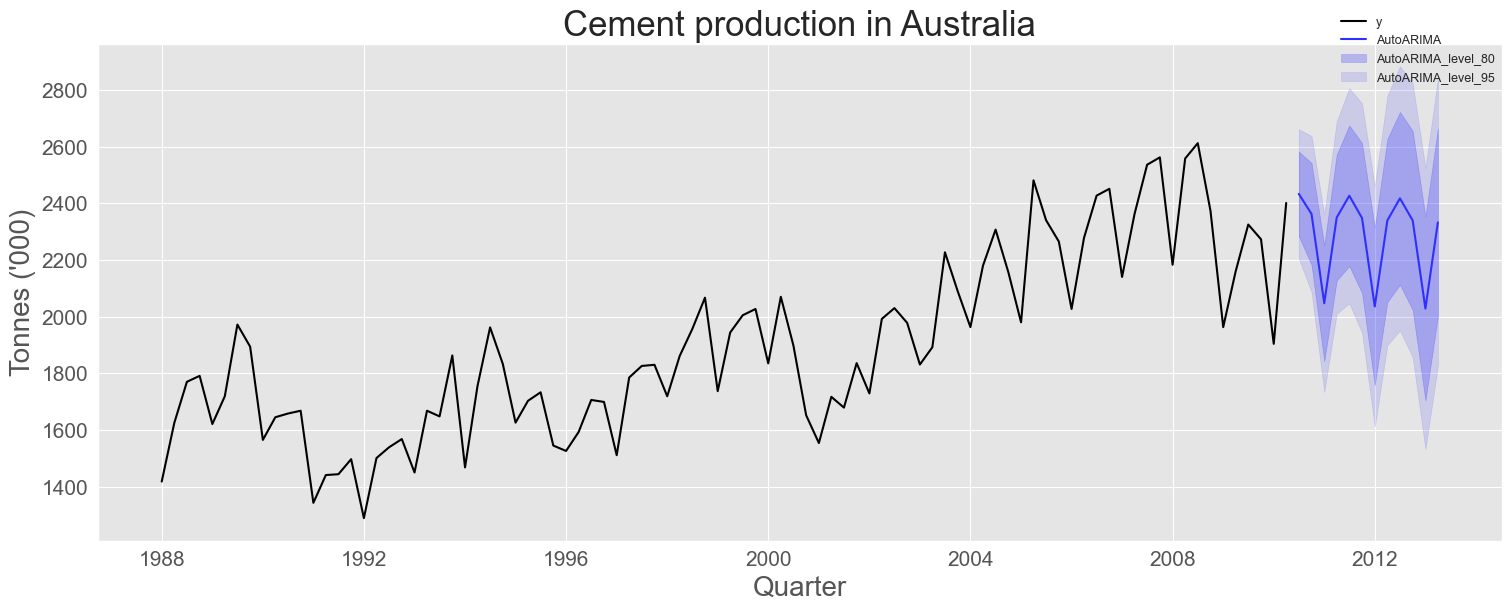

In [55]:
models = [AutoARIMA(season_length=4)]
sf = StatsForecast(models=models, freq="QS", n_jobs=-1)
fc = sf.forecast(h=12, df=cement, level=[80, 95])

plot_series(cement, fc, level=[80, 95],
    xlabel="Quarter", ylabel="Tonnes ('000)",
    title="Cement production in Australia",
    palette="black_and_blue", rm_legend=False)